# Part 2 — Benchmark Forecasting Models

This notebook implements four simple benchmark models (Mean, Naive, Seasonal
Naive, and Drift) and forecasts the final two years of weekly electricity
demand. These baselines set the standard that all advanced models must beat —
the seasonal-naive model being the key reference for strongly seasonal data.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import os, shutil, sys

# Clone the repo if the runtime was reset
if not os.path.exists("/content/electricity-demand-forecasting"):
    !git clone https://github.com/iisratislam/electricity-demand-forecasting.git

%cd /content/electricity-demand-forecasting

# Bring the dataset in from Drive
os.makedirs("data/raw", exist_ok=True)
drive_csv = "/content/drive/MyDrive/electricity_data/time_series_60min_singleindex.csv"
target    = "data/raw/time_series_60min_singleindex.csv"
if not os.path.exists(target):
    shutil.copy(drive_csv, target)

# Make the src package importable
sys.path.append("src")
print("Environment ready.")
!ls src/electricity_demand/

/content/electricity-demand-forecasting
Environment ready.
data.py  __init__.py  models


## Loading data and creating the train/test split

We rebuild the weekly series using our data module, then split it into a
training set and a **104-week (two-year) test set**. Because this is a
time-series problem, the split is strictly chronological — never random —
so that we only ever forecast the future using the past.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from electricity_demand.data import load_raw_load, to_weekly_gw

# Rebuild the weekly mean-load series (GW) from the raw file
weekly = to_weekly_gw(load_raw_load("data/raw/time_series_60min_singleindex.csv"))

TEST_WEEKS = 104                      # two-year forecast horizon
train = weekly.iloc[:-TEST_WEEKS]
test  = weekly.iloc[-TEST_WEEKS:]

print(f"Train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)} weeks)")
print(f"Test : {test.index.min().date()} -> {test.index.max().date()} ({len(test)} weeks)")

Train: 2015-01-04 -> 2018-10-07 (197 weeks)
Test : 2018-10-14 -> 2020-10-04 (104 weeks)


## The benchmark forecasting models

We implement the four benchmarks as reusable, documented functions in
`src/electricity_demand/models/benchmarks.py`. Keeping them in the package
(rather than only in the notebook) means the pipeline and tests can reuse them.

- **Mean** — predicts the training average for every future week.
- **Naive** — predicts the last observed value for every future week.
- **Seasonal Naive** — predicts each week using the same week one year earlier.
- **Drift** — extends the average trend line from the training data.

In [5]:
%%writefile src/electricity_demand/models/benchmarks.py
"""
benchmarks.py
-------------
Simple benchmark forecasting models for weekly electricity demand.

These provide the baselines that all advanced models must beat. The
seasonal-naive model is the most important reference for strongly seasonal
series such as electricity load.
"""

from __future__ import annotations
import numpy as np
import pandas as pd


def mean_forecast(train: pd.Series, horizon: int, index: pd.Index) -> pd.Series:
    """
    Forecast every future point as the mean of the training data.

    Parameters
    ----------
    train : pd.Series
        Training series.
    horizon : int
        Number of steps to forecast.
    index : pd.Index
        Datetime index to assign to the forecast (the test index).

    Returns
    -------
    pd.Series
        Constant forecast equal to the training mean.
    """
    return pd.Series(train.mean(), index=index, name="mean")


def naive_forecast(train: pd.Series, horizon: int, index: pd.Index) -> pd.Series:
    """
    Forecast every future point as the last observed training value.

    Parameters
    ----------
    train : pd.Series
        Training series.
    horizon : int
        Number of steps to forecast.
    index : pd.Index
        Datetime index to assign to the forecast.

    Returns
    -------
    pd.Series
        Constant forecast equal to the final training observation.
    """
    return pd.Series(train.iloc[-1], index=index, name="naive")


def seasonal_naive_forecast(train: pd.Series, horizon: int,
                            seasonality: int, index: pd.Index) -> pd.Series:
    """
    Forecast each point as the value observed one season earlier.

    For weekly data with annual seasonality, this predicts each week using the
    same week of the previous year. It is the key benchmark for this study.

    Parameters
    ----------
    train : pd.Series
        Training series.
    horizon : int
        Number of steps to forecast.
    seasonality : int
        Season length in steps (52 for weekly annual seasonality).
    index : pd.Index
        Datetime index to assign to the forecast.

    Returns
    -------
    pd.Series
        Seasonal-naive forecast.
    """
    last_season = train.iloc[-seasonality:].values
    # Repeat the last observed season forward to cover the whole horizon
    reps = int(np.ceil(horizon / seasonality))
    values = np.tile(last_season, reps)[:horizon]
    return pd.Series(values, index=index, name="seasonal_naive")


def drift_forecast(train: pd.Series, horizon: int, index: pd.Index) -> pd.Series:
    """
    Forecast by extending the average trend (drift) from the training data.

    The drift is the average step change between the first and last training
    points; the forecast continues this straight line into the future.

    Parameters
    ----------
    train : pd.Series
        Training series.
    horizon : int
        Number of steps to forecast.
    index : pd.Index
        Datetime index to assign to the forecast.

    Returns
    -------
    pd.Series
        Linear drift forecast.
    """
    slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
    values = train.iloc[-1] + slope * np.arange(1, horizon + 1)
    return pd.Series(values, index=index, name="drift")

Writing src/electricity_demand/models/benchmarks.py


## Generating the benchmark forecasts

We import the four benchmark functions and produce a two-year (104-week)
forecast over the test period. Each returns a forecast aligned to the test
dates, ready for plotting and evaluation.

In [6]:
from electricity_demand.models.benchmarks import (
    mean_forecast, naive_forecast, seasonal_naive_forecast, drift_forecast,
)

h = len(test)   # forecast horizon = 104 weeks

forecasts = {
    "mean":           mean_forecast(train, h, test.index),
    "naive":          naive_forecast(train, h, test.index),
    "seasonal_naive": seasonal_naive_forecast(train, h, 52, test.index),
    "drift":          drift_forecast(train, h, test.index),
}

# Preview the first few values of each forecast
for name, fc in forecasts.items():
    print(f"{name:16s} first 3 values (GW): {fc.iloc[:3].round(2).tolist()}")

mean             first 3 values (GW): [55.65, 55.65, 55.65]
naive            first 3 values (GW): [54.29, 54.29, 54.29]
seasonal_naive   first 3 values (GW): [56.33, 56.56, 57.69]
drift            first 3 values (GW): [54.32, 54.36, 54.4]


## Visualising the benchmark forecasts

We plot each benchmark against the actual test demand. This reveals visually
which methods capture the annual seasonal wave and which fall flat — building
intuition before we compute formal error metrics.

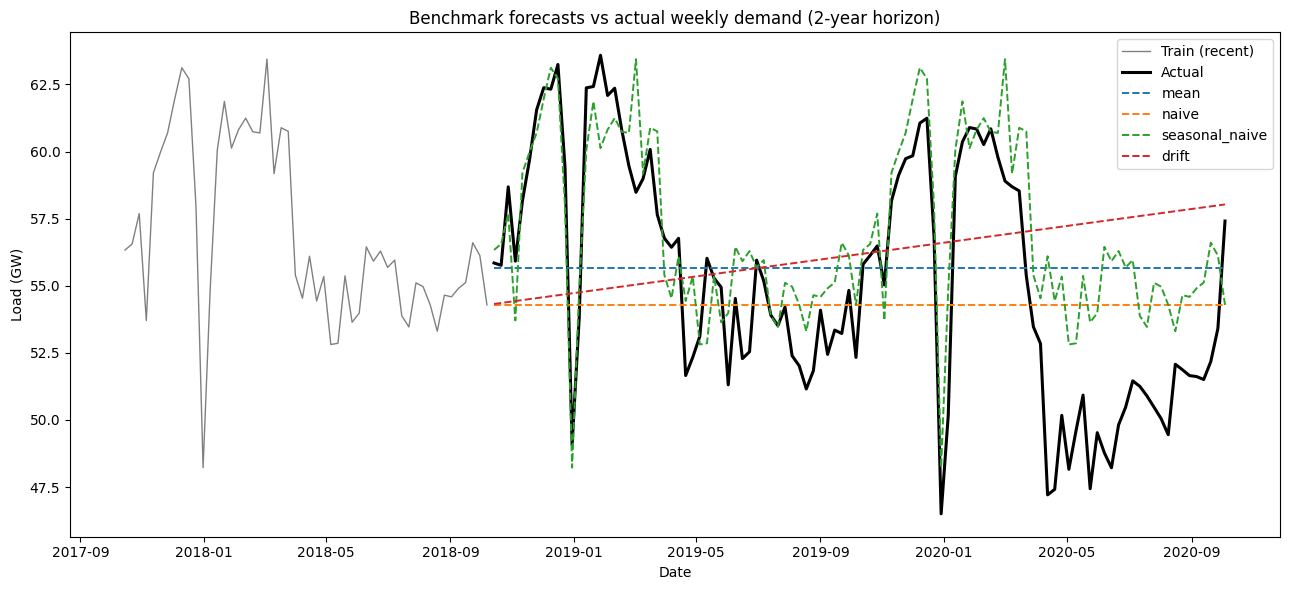

In [7]:
plt.figure(figsize=(13, 6))

# Show the last year of training for context, then the actual test data
plt.plot(train.index[-52:], train.iloc[-52:], color="grey", lw=1, label="Train (recent)")
plt.plot(test.index, test, color="black", lw=2.2, label="Actual")

# Overlay each benchmark forecast
for name, fc in forecasts.items():
    plt.plot(test.index, fc, lw=1.4, ls="--", label=name)

plt.title("Benchmark forecasts vs actual weekly demand (2-year horizon)")
plt.ylabel("Load (GW)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/02_benchmarks.png", dpi=150, bbox_inches="tight")
plt.show()

## Evaluating the benchmarks

We quantify forecast accuracy using four metrics:

- **MAE** — mean absolute error (average size of errors, in GW).
- **RMSE** — root mean squared error (penalises large errors more heavily).
- **MASE** — mean absolute scaled error; scaled against the in-sample
  seasonal-naive error. MASE < 1 means the model beats seasonal naive.
- **Bias** — mean error; positive means the model over-predicts on average.

These live in `src/electricity_demand/evaluation.py` for reuse across the project.

In [8]:
%%writefile src/electricity_demand/evaluation.py
"""
evaluation.py
-------------
Forecast evaluation metrics for the electricity demand study.

MASE (mean absolute scaled error) is the headline metric: it scales the error
by the in-sample seasonal-naive error, so a value below 1 means the model
outperforms a seasonal-naive forecast.
"""

from __future__ import annotations
import numpy as np
import pandas as pd


def mase(y_true: pd.Series, y_pred: pd.Series,
         y_train: pd.Series, seasonality: int = 52) -> float:
    """
    Mean Absolute Scaled Error, scaled by the in-sample seasonal-naive error.

    Parameters
    ----------
    y_true, y_pred : pd.Series
        Actual and predicted test values.
    y_train : pd.Series
        Training series (used to compute the scaling factor).
    seasonality : int, default 52
        Season length used by the seasonal-naive scaling.

    Returns
    -------
    float
        MASE. Below 1.0 indicates the forecast beats seasonal naive.
    """
    naive_errors = np.abs(y_train.iloc[seasonality:].values
                          - y_train.iloc[:-seasonality].values)
    scale = naive_errors.mean()
    return np.mean(np.abs(y_true.values - y_pred.values)) / scale


def evaluate_forecast(name: str, y_true: pd.Series, y_pred: pd.Series,
                      y_train: pd.Series) -> dict:
    """
    Compute MAE, RMSE, MASE, and Bias for a single forecast.

    Parameters
    ----------
    name : str
        Model name (for the results table).
    y_true, y_pred : pd.Series
        Actual and predicted test values.
    y_train : pd.Series
        Training series (needed for MASE scaling).

    Returns
    -------
    dict
        Dictionary of metrics for this model.
    """
    y_pred = y_pred.reindex(y_true.index)   # align on the test index
    errors = y_pred.values - y_true.values

    return {
        "model": name,
        "MAE":  np.mean(np.abs(errors)),
        "RMSE": np.sqrt(np.mean(errors ** 2)),
        "MASE": mase(y_true, y_pred, y_train),
        "Bias": np.mean(errors),
    }

Writing src/electricity_demand/evaluation.py


In [9]:
from electricity_demand.evaluation import evaluate_forecast

results = [
    evaluate_forecast(name, test, fc, train)
    for name, fc in forecasts.items()
]

results_df = pd.DataFrame(results).sort_values("MASE").reset_index(drop=True)
print(results_df.round(3).to_string(index=False))

         model   MAE  RMSE  MASE   Bias
seasonal_naive 2.319 3.007 1.732  1.732
         naive 3.783 4.459 2.827 -0.882
          mean 3.789 4.397 2.831  0.481
         drift 4.340 5.118 3.243  1.007


In [10]:
import os
os.makedirs("outputs/forecasts", exist_ok=True)
os.makedirs("outputs/metrics", exist_ok=True)

# Save all benchmark forecasts alongside the actual values
forecast_df = pd.DataFrame({"actual": test})
for name, fc in forecasts.items():
    forecast_df[name] = fc.reindex(test.index)
forecast_df.to_csv("outputs/forecasts/benchmark_forecasts.csv")

# Save the metrics table
results_df.to_csv("outputs/metrics/benchmark_metrics.csv", index=False)

print("Saved benchmark forecasts and metrics.")

Saved benchmark forecasts and metrics.
